## 2. Analisi di un dataset di video giochi

In [2]:
%conda install pandas
%conda install matplotlib
%conda install seaborn

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest 

In [3]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


1. Quanti videogiochi sono stati pubblicati

In [4]:
len(df)

16598

2. Quali sono i generi più popolari? Mostralo con un bar plot

In [6]:
genre_popularity = df['Genre'].value_counts().reset_index()
genre_popularity

,Genre,count
0,Action,3316
1,Sports,2346
2,Misc,1739
3,Role-Playing,1488
4,Shooter,1310
5,Adventure,1286
6,Racing,1249
7,Platform,886
8,Simulation,867
9,Fighting,848


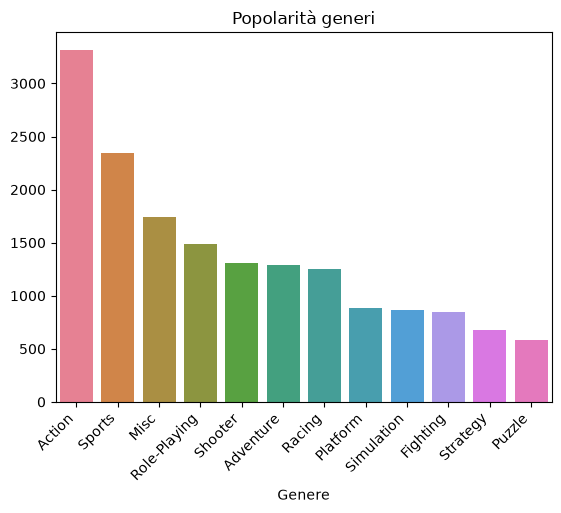

In [7]:
sns.barplot(data=genre_popularity, x='Genre', y='count', hue='Genre')
plt.title('Popolarità generi')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genere')
plt.ylabel('')
plt.show()

3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo

In [8]:
games_evolution = df['Year'].value_counts().reset_index().sort_values(by='Year', ascending=True)
games_evolution

,Year,count
36,1980.0,9
24,1981.0,46
27,1982.0,36
30,1983.0,17
35,1984.0,14
34,1985.0,14
28,1986.0,21
32,1987.0,16
33,1988.0,15
29,1989.0,17


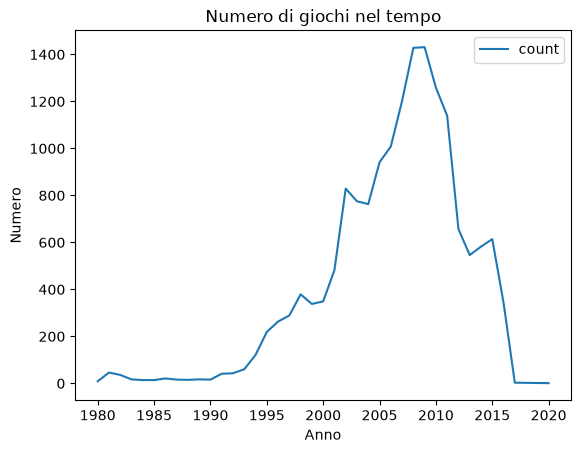

In [9]:
games_evolution.plot(x='Year' ,y='count', kind='line')
plt.title('Numero di giochi nel tempo')
plt.xlabel('Anno')
plt.ylabel('Numero')
plt.show()

4. Prova a riprodurre questo plot

In [10]:
# Creo un dataframe con la somma delle vendite di tutti gli anni
games_data = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
games_data

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Adventure,105.80,64.13,52.07,16.81
Fighting,223.59,101.32,87.35,36.68
Misc,410.24,215.98,107.76,75.32
Platform,447.05,201.63,130.77,51.59
Puzzle,123.78,50.78,57.31,12.55
Racing,359.42,238.39,56.69,77.27
Role-Playing,327.28,188.06,352.31,59.61
Shooter,582.60,313.27,38.28,102.69


In [11]:
# Filtro solo per i giochi interessati
games_data_filtered = games_data.iloc[[0, 3, 7, 8, 10],:]
games_data_filtered

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Misc,410.24,215.98,107.76,75.32
Role-Playing,327.28,188.06,352.31,59.61
Shooter,582.60,313.27,38.28,102.69
Sports,683.35,376.85,135.37,134.97


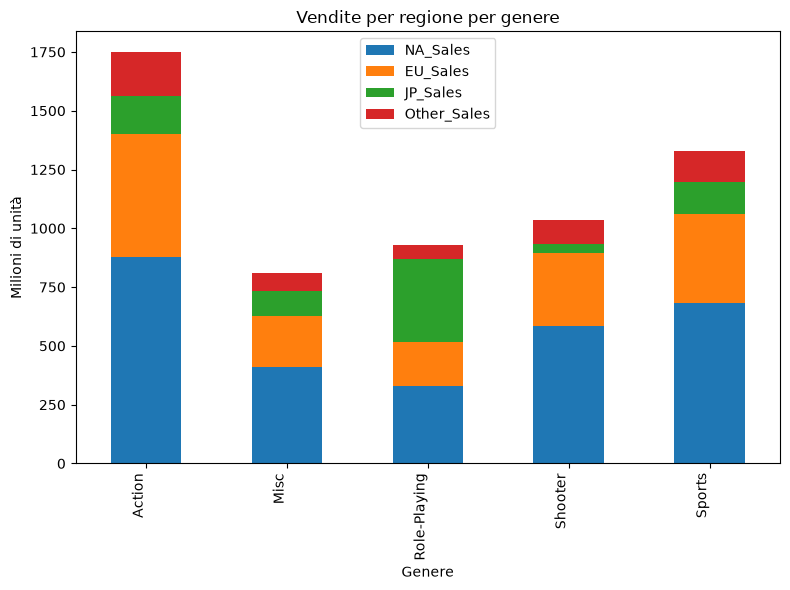

In [12]:
games_data_filtered.plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Vendite per regione per genere')
plt.legend(loc='upper center')
plt.xlabel('Genere')
plt.ylabel('Milioni di unità')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()